# Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import warnings
import pylab as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import explained_variance_score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
warnings.filterwarnings("ignore")

# Ex1 (3 points): 

- Read the dataset labtop_data
- Identify numerical variables
- Identify boolean variables and convert them into 0/1 variables
- Integrate numerical and 0/1 variables
- Delete variable with title 'product_ean'
- Delete columns with a percentage of NAs greater or equal than 25%
- With the resulting table, delete rows involving NAs. 


In [21]:
df = pd.read_csv('data\labtop_data.csv', sep = ',')

In [22]:
numeric = df.select_dtypes(include=['number']).columns
print(numeric)

Index(['price_eur', 'display_inch', 'display_cm', 'weight_kg', 'height_mm',
       'width_mm', 'depth_mm', 'ram_memory', 'internal_storage_gb',
       'battery_life_h', 'battery_capacity_wh', 'psu_watts', 'speakers_count',
       'product_ean', 'release_year'],
      dtype='object')


In [23]:
boolean = df.select_dtypes(include=['boolean']).columns
print(boolean)
df[boolean] = df[boolean].astype(int)

Index(['has_touchscreen', 'keyboard_backlit', 'keyboard_numpad', 'has_webcam',
       'has_bluetooth'],
      dtype='object')


In [35]:
numeric_values = df[numeric]
boolean_values = df[boolean]

df2 = pd.concat([numeric_values,boolean_values], axis = 1)
df2.head()

,price_eur,display_inch,display_cm,weight_kg,height_mm,width_mm,depth_mm,ram_memory,internal_storage_gb,battery_life_h,battery_capacity_wh,psu_watts,speakers_count,product_ean,release_year,has_touchscreen,keyboard_backlit,keyboard_numpad,has_webcam,has_bluetooth
0,912.99,13.0,33.8,1.29,16.1,304.1,212.4,8.0,256.0,18.0,49.9,30.0,2.0,1.942521e+11,2020.0,0,1,0,1,1
1,4680.23,17.3,43.9,2.80,20.1,397.6,283.5,64.0,4.0,NaN,99.0,240.0,2.0,4.711377e+12,NaN,0,1,1,1,1
2,1651.12,14.0,35.6,1.60,17.9,314.0,227.5,16.0,1000.0,NaN,72.0,65.0,2.0,4.719073e+12,NaN,1,1,0,1,1
3,1087.38,15.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.719332e+12,NaN,0,0,0,0,0
4,354.97,15.6,39.6,1.95,23.9,361.0,244.0,8.0,256.0,NaN,45.0,NaN,2.0,4.065221e+12,NaN,0,0,1,1,1


In [36]:
df2 = df2.drop('product_ean', axis = 1)
df2.head()

,price_eur,display_inch,display_cm,weight_kg,height_mm,width_mm,depth_mm,ram_memory,internal_storage_gb,battery_life_h,battery_capacity_wh,psu_watts,speakers_count,release_year,has_touchscreen,keyboard_backlit,keyboard_numpad,has_webcam,has_bluetooth
0,912.99,13.0,33.8,1.29,16.1,304.1,212.4,8.0,256.0,18.0,49.9,30.0,2.0,2020.0,0,1,0,1,1
1,4680.23,17.3,43.9,2.80,20.1,397.6,283.5,64.0,4.0,NaN,99.0,240.0,2.0,NaN,0,1,1,1,1
2,1651.12,14.0,35.6,1.60,17.9,314.0,227.5,16.0,1000.0,NaN,72.0,65.0,2.0,NaN,1,1,0,1,1
3,1087.38,15.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
4,354.97,15.6,39.6,1.95,23.9,361.0,244.0,8.0,256.0,NaN,45.0,NaN,2.0,NaN,0,0,1,1,1


In [37]:
umbral = 0.25
cols_to_keep = df2.columns[df2.isnull().mean()<umbral]
df2 = df2[cols_to_keep]
df2.head()

,price_eur,display_inch,display_cm,weight_kg,height_mm,width_mm,depth_mm,ram_memory,internal_storage_gb,battery_capacity_wh,psu_watts,has_touchscreen,keyboard_backlit,keyboard_numpad,has_webcam,has_bluetooth
0,912.99,13.0,33.8,1.29,16.1,304.1,212.4,8.0,256.0,49.9,30.0,0,1,0,1,1
1,4680.23,17.3,43.9,2.80,20.1,397.6,283.5,64.0,4.0,99.0,240.0,0,1,1,1,1
2,1651.12,14.0,35.6,1.60,17.9,314.0,227.5,16.0,1000.0,72.0,65.0,1,1,0,1,1
3,1087.38,15.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
4,354.97,15.6,39.6,1.95,23.9,361.0,244.0,8.0,256.0,45.0,NaN,0,0,1,1,1


In [38]:
df2 = df2.dropna()
df2.head()

,price_eur,display_inch,display_cm,weight_kg,height_mm,width_mm,depth_mm,ram_memory,internal_storage_gb,battery_capacity_wh,psu_watts,has_touchscreen,keyboard_backlit,keyboard_numpad,has_webcam,has_bluetooth
0,912.99,13.0,33.8,1.29,16.1,304.1,212.4,8.0,256.0,49.9,30.0,0,1,0,1,1
1,4680.23,17.3,43.9,2.80,20.1,397.6,283.5,64.0,4.0,99.0,240.0,0,1,1,1,1
2,1651.12,14.0,35.6,1.60,17.9,314.0,227.5,16.0,1000.0,72.0,65.0,1,1,0,1,1
5,1997.16,14.0,35.6,1.12,15.4,315.6,222.5,16.0,512.0,57.0,65.0,0,1,0,1,1
6,1098.00,13.6,34.5,1.24,11.3,304.1,215.0,8.0,256.0,52.6,30.0,0,1,0,1,1


# Ex2 (4 points): 

- Build an elastic net model to predict the price of computers
- Use 1/5 of data for training and 4/5 of data for test
- Use 5-folds CV to fix optimal parameters in the training process
- Use explained variance as a metric of the goodness of the fit
- Determine the most relevant features. 
- Note: consider scaling data.
- Plot an scatterplot with test and predicted outcome.
- Calculate the corrlation (spearman) between test and predicted outcome 


Esta es la solución al examen de ese año. Hay un fallo en el modelo de Machine Learning.
La idea es intentar ver donde está el error (sin preguntar a ninguna IA)

In [39]:
Y= data3['price_eur']
X= data3.drop(['price_eur'], axis=1)

scaler = StandardScaler()
X = scaler.fit_transform(X)
mean = np.mean(Y)
std_dev = np.std(Y)
Y = (Y - mean) / std_dev

m = 11
l1 = np.linspace(0,1,m)
alphas = np.logspace(-5,5,11)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=1/5, random_state=10)

m1 = ElasticNetCV(alphas=alphas, cv=5, random_state=0,
                          l1_ratio=l1).fit(X_train, Y_train)


ypred = m1.predict(X_train)

evar_train = explained_variance_score(Y_train, ypred)

ypred = m1.predict(X_test)
evar_test = explained_variance_score(Y_test, ypred)


print("Explained variance in training data is: ", evar_train)
print("Explained variance in test data is: ", evar_test)

betas = m1.coef_
n_features = sum(abs(betas)>0)
print("Number of features with ElasticNet: ", n_features)

NameError: name 'data3' is not defined

Explained Variance in train:  0.6264473404400328
Explained Variance in test:  0.5165934749218664
Correlation in train:  0.6453629321367294
Correlation in test:  0.5970312468717806
Number of features with ElasticNet:  15

=== DIAGNÓSTICO ===

Mejor alpha: 1.0
Mejor l1_ratio: 0.0
Features activas: 15/15
Train explained var: 0.6264
Test explained var: 0.5166


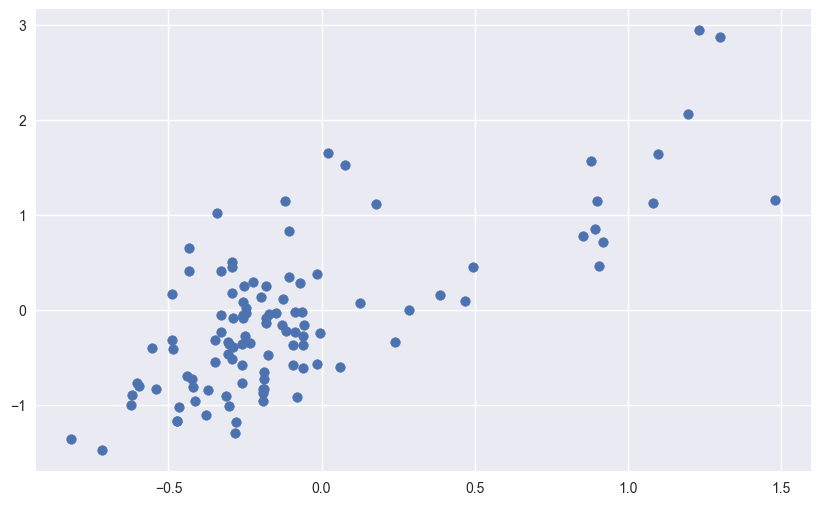

In [67]:
from scipy.stats import spearmanr

X = df2.drop(columns = ['price_eur'])
Y = df2['price_eur']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size= 0.2, random_state=29)

Xscaler = StandardScaler()
X_train_scaled = Xscaler.fit_transform(X_train)
X_test_scaled = Xscaler.transform(X_test)

Yscaler = StandardScaler()
Y_train_scaled = Yscaler.fit_transform(Y_train.values.reshape(-1,1)).ravel()
Y_test_scaled = Yscaler.transform(Y_test.values.reshape(-1,1)).ravel()

l1_ratios = np.linspace(0, 1, 11)
alphas = np.logspace(-10, 10, 11)

elastic_cv = ElasticNetCV(l1_ratio= l1_ratios, cv = 5, random_state= 0, alphas= alphas)
elastic_cv.fit(X_train_scaled, Y_train_scaled)

Y_pred_train = elastic_cv.predict(X_train_scaled)
Y_pred_test = elastic_cv.predict(X_test_scaled)

explained_var_train = explained_variance_score(Y_train_scaled, Y_pred_train)
explained_var_test = explained_variance_score(Y_test_scaled, Y_pred_test)

corr_train = spearmanr(Y_train_scaled, Y_pred_train)[0]
corr_test = spearmanr(Y_test_scaled, Y_pred_test)[0]

betas = elastic_cv.coef_
n_features = sum(abs(betas)>0)

print('Explained Variance in train: ', explained_var_train)
print('Explained Variance in test: ', explained_var_test)
print('Correlation in train: ', corr_train)
print('Correlation in test: ', corr_test)
print('Number of features with ElasticNet: ', n_features)
print("\n=== DIAGNÓSTICO ===\n")
print(f"Mejor alpha: {elastic_cv.alpha_}")
print(f"Mejor l1_ratio: {elastic_cv.l1_ratio_}")
print(f"Features activas: {n_features}/{X_train_scaled.shape[1]}")
print(f"Train explained var: {explained_var_train:.4f}")
print(f"Test explained var: {explained_var_test:.4f}")

plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8')
plt.scatter(Y_pred_test, Y_test_scaled)




# Ex3 (3 points): 

- Apply K-means clustering without using price.
- To select the number of clusters, use the Silhouette index.
- Plot Silhouette index for different K values
- Consider the complexity of the solution to select K
- visualize groups with PCA